In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
processedData = Path('../data/processed')
df = pd.read_csv(processedData / 'gdp_cleaned.csv')
df_long = df.melt(id_vars="Country", var_name="Year", value_name="GDP")
df_long["Year"] = df_long["Year"].astype(int)

In [5]:
global_stats = (
    df_long.groupby("Year")["GDP"]
    .agg(total="sum", mean="mean", median="median")
    .reset_index()
)
global_stats.round(2)

,Year,total,mean,median
0,2020,85764148.0,442083.24,35334.5
1,2021,97843985.0,504350.44,37719.0
2,2022,101948238.0,525506.38,41568.0
3,2023,106431753.0,548617.28,43631.0
4,2024,110560167.3,569897.77,45466.0
5,2025,113713923.9,586154.25,46782.0


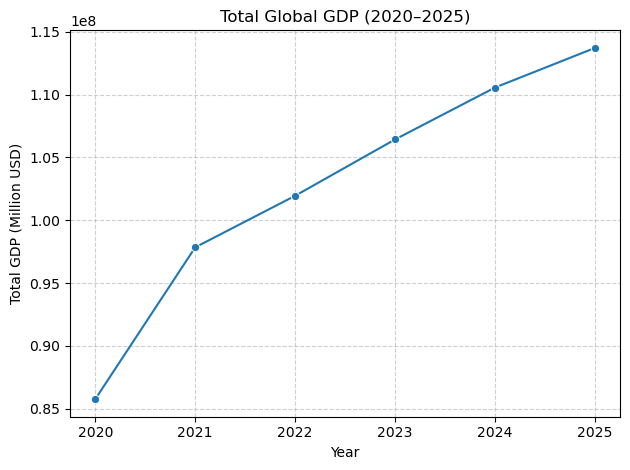

In [6]:
plt.figure()
sns.lineplot(data=global_stats, x="Year", y="total", marker="o")
plt.title("Total Global GDP (2020–2025)")
plt.ylabel("Total GDP (Million USD)")
plt.xlabel("Year")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


The total world GDP rose steadily after 2020, showing recovery after COVID-19 slowdowns.
Global GDP grew 32.58% from 2020 to 2025

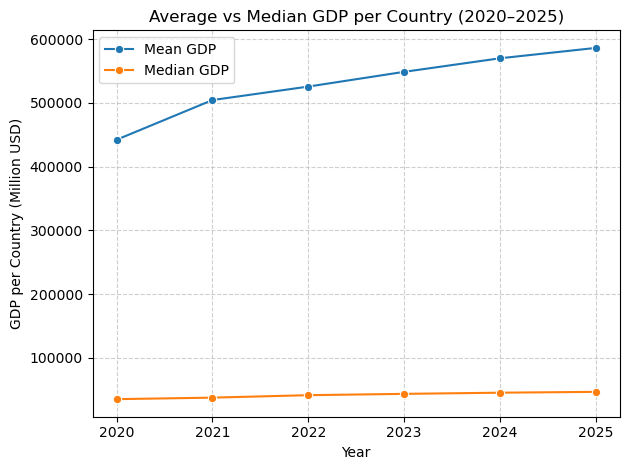

In [7]:
plt.figure()
sns.lineplot(data=global_stats, x="Year", y="mean", marker="o", label="Mean GDP")
sns.lineplot(data=global_stats, x="Year", y="median", marker="o", label="Median GDP")
plt.title("Average vs Median GDP per Country (2020–2025)")
plt.ylabel("GDP per Country (Million USD)")
plt.xlabel("Year")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


The gap between the mean and median reflects inequality among countries:
a wide gap means a few very large economies (US, China) dominate.
If the lines converge slightly, smaller economies grew faster.

In [11]:
global_stats["YoY_total_%"] = global_stats["total"].pct_change() * 100
global_stats["YoY_total_%"] = global_stats["YoY_total_%"].fillna(0)
global_stats.round(2)

,Year,total,mean,median,YoY_total_%
0,2020,85764148.0,442083.24,35334.5,0.00
1,2021,97843985.0,504350.44,37719.0,14.08
2,2022,101948238.0,525506.38,41568.0,4.19
3,2023,106431753.0,548617.28,43631.0,4.40
4,2024,110560167.3,569897.77,45466.0,3.88
5,2025,113713923.9,586154.25,46782.0,2.85


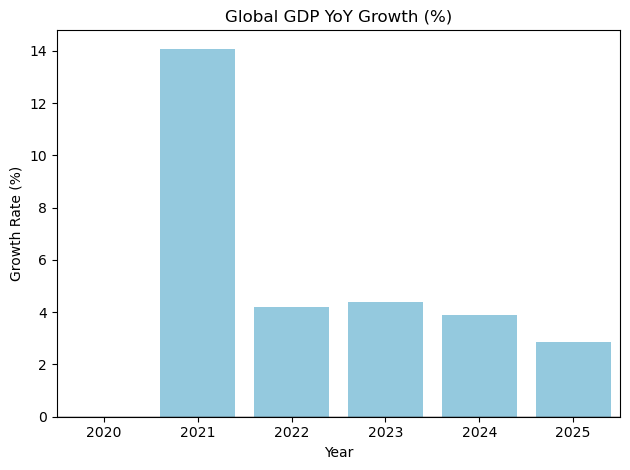

In [12]:
plt.figure()
sns.barplot(data=global_stats, x="Year", y="YoY_total_%", color="skyblue")
plt.axhline(0, color='black', linewidth=1)
plt.title("Global GDP YoY Growth (%)")
plt.ylabel("Growth Rate (%)")
plt.xlabel("Year")
plt.tight_layout()
plt.show()


Although global GDP continues to increase after 2021, the YoY growth rate peaks in 2021.
This reflects a strong rebound after the 2020 COVID-19 shutdowns slowdown, followed by steady but slower growth through 2025.
In other words, the economy kept expanding — just at a decreasing rate of acceleration.

Global GDP increased from $85.764 trillion to $113.714 trillion between 2020 and 2025

Growth was strongest in 2021, reflecting post-pandemic recovery

The mean GDP per country remained far higher than the median, showing persisten global economic domination

From 2024–2025, missing or incomplete data may slightly understate global totals.

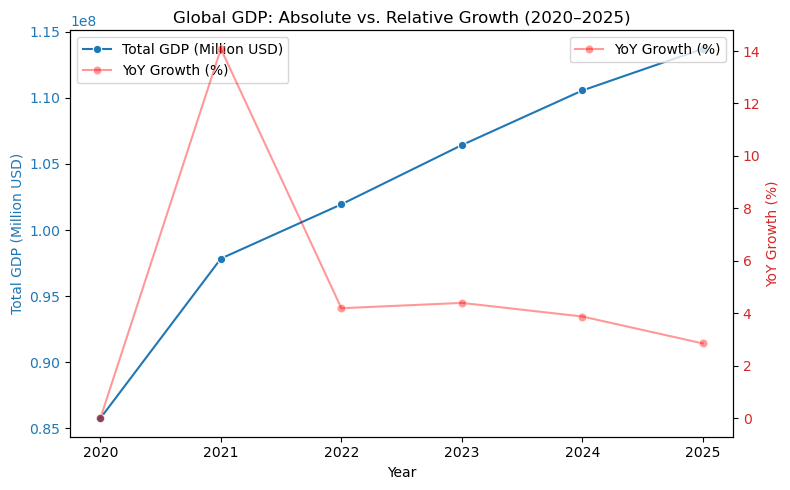

In [18]:
fig, ax1 = plt.subplots(figsize=(8,5))

# --- Left axis: total GDP (line) ---
sns.lineplot(
    data=global_stats,
    x="Year", y="total", marker="o", color="tab:blue", ax=ax1, label="Total GDP (Million USD)"
)
ax1.set_ylabel("Total GDP (Million USD)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# --- Right axis: YoY growth (%) ---
ax2 = ax1.twinx()  # share same x-axis
sns.lineplot(
    data=global_stats,
    x="Year", y="YoY_total_%",marker='o', color="red", alpha=0.4, ax=ax2, label="YoY Growth (%)"
)
ax2.set_ylabel("YoY Growth (%)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# --- Title & legend ---
plt.title("Global GDP: Absolute vs. Relative Growth (2020–2025)")
fig.tight_layout()

# combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")

plt.show()

Total global GDP rises steadily through 2025, indicating continuous expansion.
However, YoY growth peaked sharply in 2021 (~14%), a rebound following 2020’s pandemic shutdonws.

Afterward, growth remained positive but slowed, suggesting stabilization rather than new acceleration

<Axes: xlabel='GDP', ylabel='Country'>

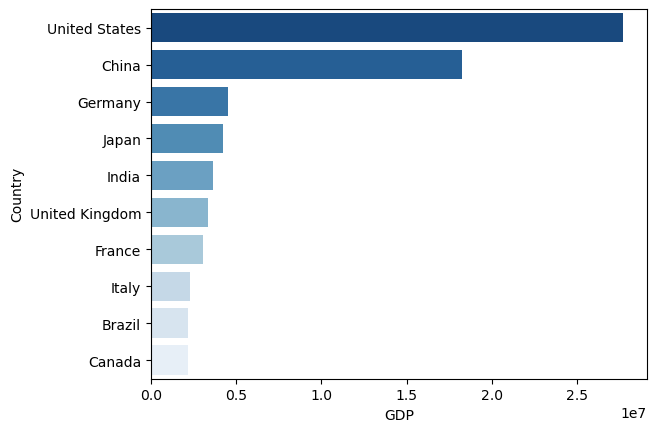

In [23]:
top2023 = (
    df_long.query("Year == 2023")
    .sort_values("GDP", ascending=False)
    .head(10)
)
sns.barplot(
    data=top2023,
    x="GDP",
    y="Country",
    hue="Country",
    palette="Blues_r",
    legend=False
)

Above are the top 10 highest GDP countries, the economic dominance gap can be clearly seen here

In [26]:
ranks = (
    df_long
    .sort_values(['Year', 'GDP'], ascending=[True, False])
    .assign(rank=lambda d: d.groupby('Year').cumcount() + 1)
)

rank_change = (
    ranks.pivot(index='Country', columns='Year', values='rank')
    .assign(rank_change_2020_2025=lambda d: d[2020] - d[2025])
    .reset_index()
    .sort_values('rank_change_2020_2025', ascending=False)
)

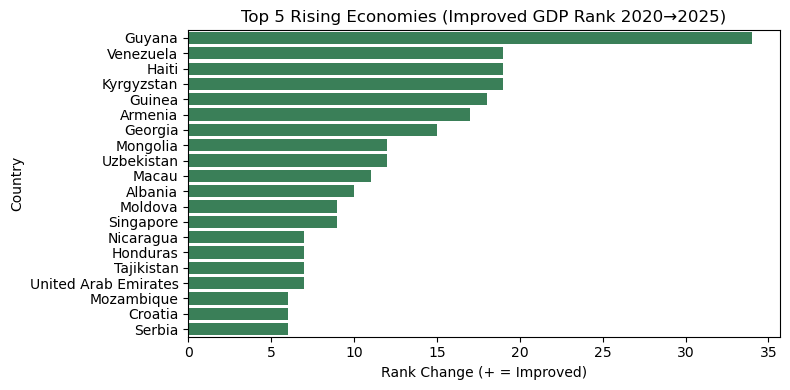

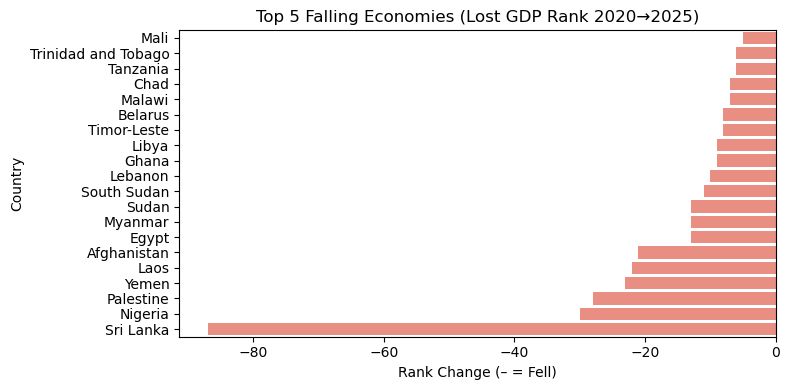

In [37]:
top_movers = rank_change.head(20)
bottom_movers = rank_change.tail(20)

plt.figure(figsize=(8,4))
sns.barplot(data=top_movers, x='rank_change_2020_2025', y='Country', color='seagreen')
plt.title("Top 5 Rising Economies (Improved GDP Rank 2020→2025)")
plt.xlabel("Rank Change (+ = Improved)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
sns.barplot(data=bottom_movers, x='rank_change_2020_2025', y='Country', color='salmon')
plt.title("Top 5 Falling Economies (Lost GDP Rank 2020→2025)")
plt.xlabel("Rank Change (– = Fell)")
plt.tight_layout()
plt.show()


These charts highlight which countries climbed or dropped in GDP ranking.
For example, Guyana's GDP grew much faster than mature economies, because of the discovery of offshore oil, while some developed nations lose relative share.

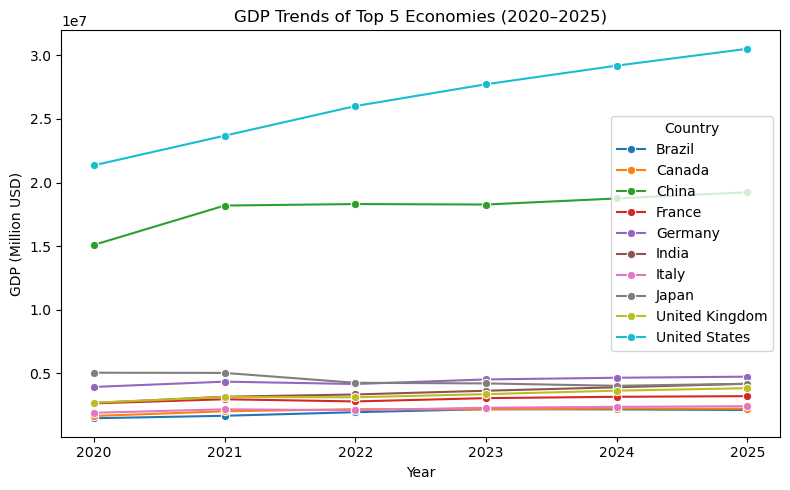

In [28]:
top5 = top2023["Country"].tolist()
subset = df_long[df_long["Country"].isin(top5)]

plt.figure(figsize=(8,5))
sns.lineplot(data=subset, x="Year", y="GDP", hue="Country", marker="o")
plt.title("GDP Trends of Top 5 Economies (2020–2025)")
plt.ylabel("GDP (Million USD)")
plt.tight_layout()
plt.show()


All five largest economies show upward trends; however, growth rates differ — developing countries (e.g., India) grow faster than mature ones (e.g., Japan).

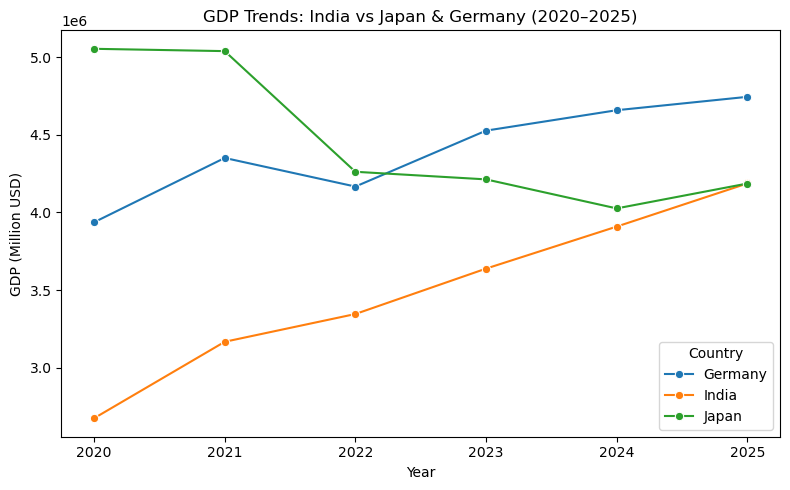

In [31]:
focus = ["India","Japan","Germany"]
subset = df_long[df_long["Country"].isin(focus)]
plt.figure(figsize=(8,5))
sns.lineplot(data=subset, x="Year", y="GDP", hue="Country", marker="o")
plt.title("GDP Trends: India vs Japan & Germany (2020–2025)")
plt.ylabel("GDP (Million USD)")
plt.tight_layout()
plt.show()


India’s line rises faster; lines converge toward Japan/Germany.

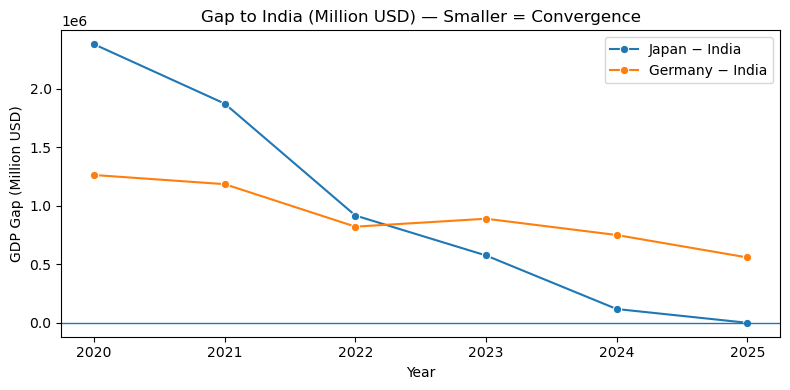

,Year,Japan−India,Germany−India
0,2020,2379217.0,1262137.0
1,2021,1871877.0,1183917.0
2,2022,916039.0,820765.0
3,2023,574677.0,888519.0
4,2024,117114.0,749429.0
5,2025,-586.0,557787.0


In [32]:
piv = df_long.pivot_table(index="Year", columns="Country", values="GDP")
gap_jp = piv["Japan"] - piv["India"]
gap_de = piv["Germany"] - piv["India"]
gap = (gap_jp.to_frame("Japan−India")
       .join(gap_de.to_frame("Germany−India"))).reset_index()
plt.figure(figsize=(8,4))
sns.lineplot(data=gap, x="Year", y="Japan−India", marker="o", label="Japan − India")
sns.lineplot(data=gap, x="Year", y="Germany−India", marker="o", label="Germany − India")
plt.title("Gap to India (Million USD) — Smaller = Convergence")
plt.ylabel("GDP Gap (Million USD)")
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()
gap

Both gap series trend downward, which shows that India is catching up.

In [34]:
def cagr(s, start=2020, end=2023):
    a, b, n = s[start], s[end], end-start
    return (b/a)**(1/n) - 1

rows = []
for c in ["India","Japan","Germany"]:
    s = piv.loc[:, c]
    if pd.notna(s.get(2020)) and pd.notna(s.get(2023)):
        rows.append({"Country": c, "CAGR_2020_2023_%": round(cagr(s)*100, 2)})

pd.DataFrame(rows).sort_values("CAGR_2020_2023_%", ascending=False)


,Country,CAGR_2020_2023_%
0,India,10.80
2,Germany,4.76
1,Japan,-5.89


India’s compound annual growth rate > Japan/Germany, which explains the narrowing gaps.

The top 5 economies remain consistent: United States, China, Japan, Germany, and India.

India shows strong upward momentum, closing the gap with Japan and Germany.

Emerging economies such as Brazil's rise in rank, while some European nations lose share.

The global GDP hierarchy remains stable overall, with modest rank reshuffling.

The dataset indicates strong rank improvements for smaller economies such as Guyana and Venezuela, likely due to sharp percentage increases from relatively low GDP bases or recent data adjustments.
However, real-world data from IMF and World Bank sources show major emerging economies like Brazil and Indonesia as the consistent risers in global rankings.
This difference likely stems from dataset scale (nominal USD, limited timeframe) and missing regional normalization.